In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid', palette='muted')


In [31]:
data = pd.read_csv('user_behavior_dataset.csv')

print(f"Shape: {data.shape}")
print(f"Rows: {data.shape[0]}  |  Columns: {data.shape[1]}\n")
data.head()

Shape: (700, 11)
Rows: 700  |  Columns: 11



,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [4]:
data.info()
data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


,User ID,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,271.128571,5.272714,1525.158571,50.681429,929.742857,38.482857,2.990000
std,202.21688,177.199484,3.068584,819.136414,26.943324,640.451729,12.012916,1.401476
min,1.00000,30.000000,1.000000,302.000000,10.000000,102.000000,18.000000,1.000000
25%,175.75000,113.250000,2.500000,722.250000,26.000000,373.000000,28.000000,2.000000
50%,350.50000,227.500000,4.900000,1502.500000,49.000000,823.500000,38.000000,3.000000
75%,525.25000,434.250000,7.400000,2229.500000,74.000000,1341.000000,49.000000,4.000000
max,700.00000,598.000000,12.000000,2993.000000,99.000000,2497.000000,59.000000,5.000000


In [32]:
missing = data.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found ")

Missing values per column:
No missing values found 


In [33]:
dupes = data.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    data.drop_duplicates(inplace=True)
    print(f"Removed. New shape: {data.shape}")

Duplicate rows: 0


In [34]:
data.drop(columns=['User ID'], inplace=True)
print("Dropped 'User ID' column.")
data.head(3)

Dropped 'User ID' column.


,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2


In [35]:
# Binary encoding: Gender and Operating System
data['Gender']           = data['Gender'].map({'Male': 0, 'Female': 1})
data['Operating System'] = data['Operating System'].map({'Android': 0, 'iOS': 1})

# Ordinal encoding: Device Model (5 unique values)
device_map = {model: idx for idx, model in enumerate(data['Device Model'].unique())}
data['Device Model'] = data['Device Model'].map(device_map)

print("Encoding map — Device Model:", device_map)
print("\nEncoded dtypes:")
print(data[['Gender', 'Operating System', 'Device Model']].dtypes)
data.head(3)

Encoding map — Device Model: {'Google Pixel 5': 0, 'OnePlus 9': 1, 'Xiaomi Mi 11': 2, 'iPhone 12': 3, 'Samsung Galaxy S21': 4}

Encoded dtypes:
Gender              int64
Operating System    int64
Device Model        int64
dtype: object


,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,0,0,393,6.4,1872,67,1122,40,0,4
1,1,0,268,4.7,1331,42,944,47,1,3
2,2,0,154,4.0,761,32,322,42,0,2


In [36]:
class_dist = data['User Behavior Class'].value_counts().sort_index()
print("Class Distribution:")
print(class_dist)
print(f"\nBalance (%):\n{(class_dist / len(data) * 100).round(2)}")

Class Distribution:
User Behavior Class
1    136
2    146
3    143
4    139
5    136
Name: count, dtype: int64

Balance (%):
User Behavior Class
1    19.43
2    20.86
3    20.43
4    19.86
5    19.43
Name: count, dtype: float64


In [37]:
feature_cols = [
    'App Usage Time (min/day)',
    'Screen On Time (hours/day)',
    'Battery Drain (mAh/day)',
    'Data Usage (MB/day)',
    'Number of Apps Installed'
]

group_summary = data.groupby('User Behavior Class')[feature_cols].mean().round(2)
print("Average Metrics per Behavior Class")
group_summary

Average Metrics per Behavior Class


,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Data Usage (MB/day),Number of Apps Installed
User Behavior Class,,,,,
1,60.43,1.49,454.98,202.32,14.56
2,131.97,3.04,883.81,451.42,30.75
3,235.40,4.96,1515.06,822.01,50.00
4,395.75,6.91,2105.81,1232.23,69.92
5,541.42,10.11,2701.01,1974.77,89.25


In [39]:
screen_ranking = (data.groupby('User Behavior Class')['Screen On Time (hours/day)']
                      .mean()
                      .sort_values(ascending=False)
                      .round(2))

print("Avg Screen-On Time per Class")
print(screen_ranking)
print(f"\n Class {screen_ranking.idxmax()} has the highest screen-on time "
      f"({screen_ranking.max()} hrs/day)")

Avg Screen-On Time per Class
User Behavior Class
5    10.11
4     6.91
3     4.96
2     3.04
1     1.49
Name: Screen On Time (hours/day), dtype: float64

 Class 5 has the highest screen-on time (10.11 hrs/day)


In [40]:
age_stats = data.groupby('User Behavior Class')['Age'].agg(
    Mean='mean', Median='median', Min='min', Max='max', Std='std'
).round(2)

print("Age Statistics per Behavior Class")
age_stats

Age Statistics per Behavior Class


,Mean,Median,Min,Max,Std
User Behavior Class,,,,,
1,38.21,37.0,18,59,11.28
2,38.64,39.0,18,59,11.60
3,38.68,38.0,18,59,12.80
4,38.68,40.0,18,59,12.65
5,38.18,37.0,18,59,11.79


In [41]:
# Gender split
gender_split = data.groupby('User Behavior Class')['Gender'].mean().round(3)
print("Proportion Female (0=Male, 1=Female) per Class")
print(gender_split)

# OS split
os_split = data.groupby('User Behavior Class')['Operating System'].mean().round(3)
print("\n Proportion iOS (0=Android, 1=iOS) per Class")
print(os_split)

Proportion Female (0=Male, 1=Female) per Class
User Behavior Class
1    0.463
2    0.438
3    0.573
4    0.482
5    0.441
Name: Gender, dtype: float64

 Proportion iOS (0=Android, 1=iOS) per Class
User Behavior Class
1    0.162
2    0.219
3    0.224
4    0.209
5    0.228
Name: Operating System, dtype: float64


In [42]:
corr_with_target = (data.corr()['User Behavior Class']
                        .drop('User Behavior Class')
                        .sort_values(ascending=False))

print("Feature Correlations with User Behavior Class")
print(corr_with_target.round(3))

Feature Correlations with User Behavior Class
Number of Apps Installed      0.981
Battery Drain (mAh/day)       0.979
App Usage Time (min/day)      0.970
Screen On Time (hours/day)    0.965
Data Usage (MB/day)           0.947
Operating System              0.041
Device Model                  0.026
Gender                        0.001
Age                          -0.001
Name: User Behavior Class, dtype: float64


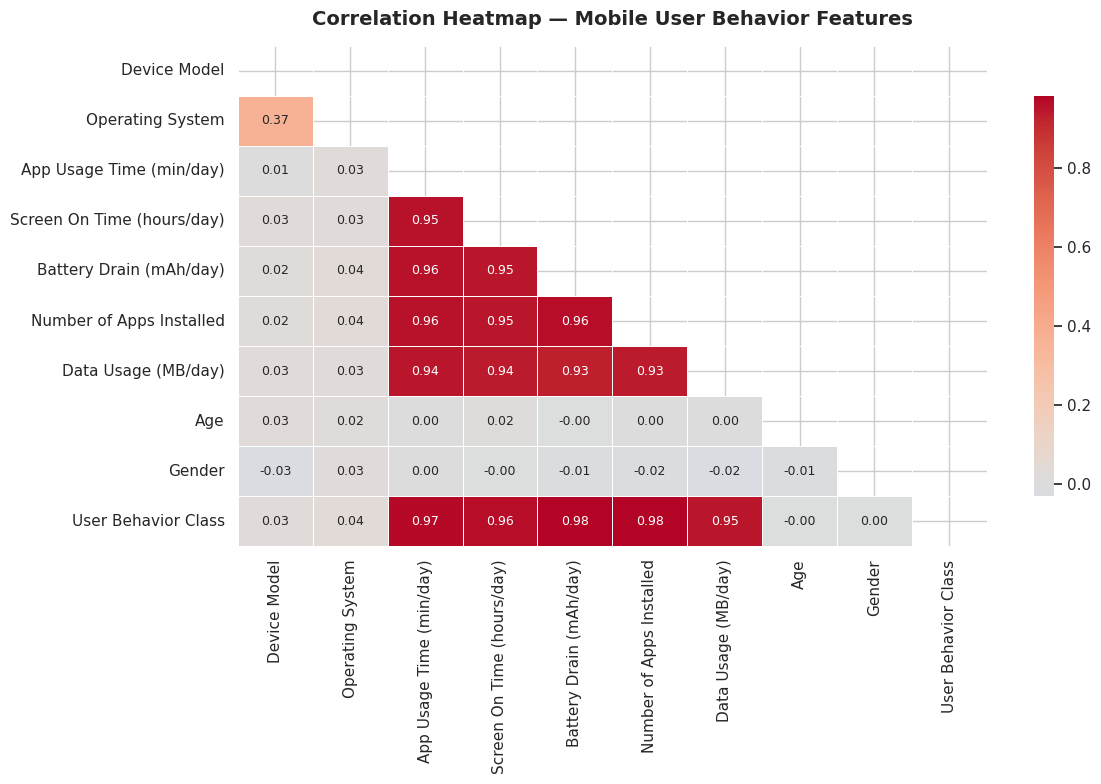

In [43]:
fig, ax = plt.subplots(figsize=(12, 8))

corr_matrix = data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # lower triangle only

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 9}, cbar_kws={'shrink': 0.8}, ax=ax
)

ax.set_title('Correlation Heatmap — Mobile User Behavior Features',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()



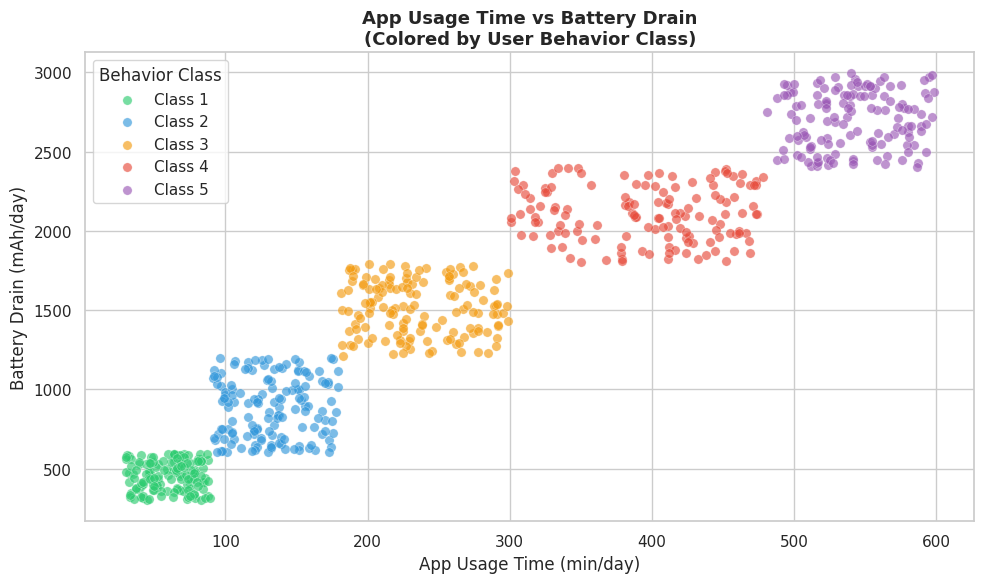

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))

palette = {1: '#2ecc71', 2: '#3498db', 3: '#f39c12', 4: '#e74c3c', 5: '#9b59b6'}

for cls in sorted(data['User Behavior Class'].unique()):
    subset = data[data['User Behavior Class'] == cls]
    ax.scatter(
        subset['App Usage Time (min/day)'],
        subset['Battery Drain (mAh/day)'],
        label=f'Class {cls}', color=palette[cls],
        alpha=0.65, s=45, edgecolors='white', linewidths=0.3
    )

ax.set_xlabel('App Usage Time (min/day)', fontsize=12)
ax.set_ylabel('Battery Drain (mAh/day)', fontsize=12)
ax.set_title('App Usage Time vs Battery Drain\n(Colored by User Behavior Class)',
             fontsize=13, fontweight='bold')
ax.legend(title='Behavior Class', framealpha=0.8)
plt.tight_layout()
plt.show()


/tmp/ipython-input-3186511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


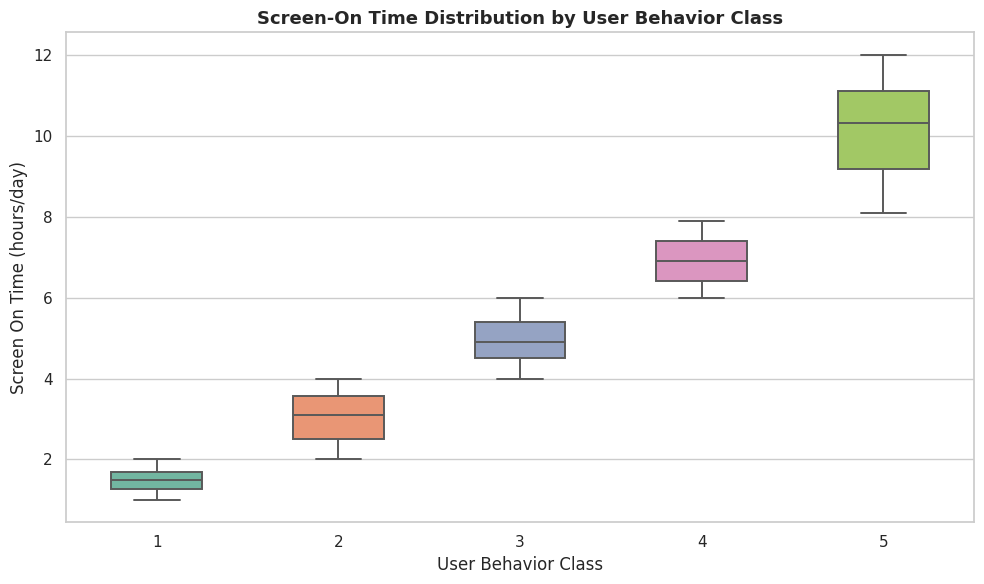

In [45]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=data, x='User Behavior Class', y='Screen On Time (hours/day)',
    palette='Set2', width=0.5, linewidth=1.4,
    flierprops=dict(marker='o', color='grey', markersize=4, alpha=0.5),
    ax=ax
)

ax.set_xlabel('User Behavior Class', fontsize=12)
ax.set_ylabel('Screen On Time (hours/day)', fontsize=12)
ax.set_title('Screen-On Time Distribution by User Behavior Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



/tmp/ipython-input-4038063896.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


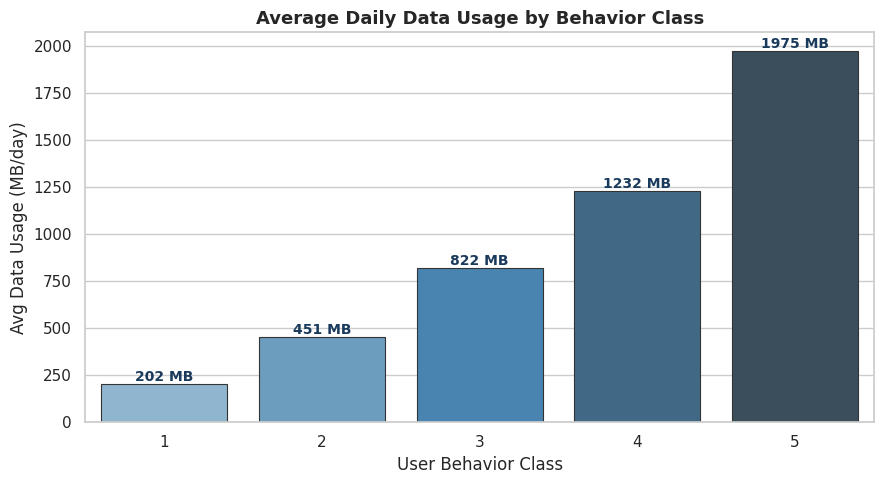

In [46]:
avg_usage = (data.groupby('User Behavior Class')['Data Usage (MB/day)']
                 .mean().reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
bars = sns.barplot(
    data=avg_usage, x='User Behavior Class', y='Data Usage (MB/day)',
    palette='Blues_d', edgecolor='#333', linewidth=0.8, ax=ax
)

for bar in bars.patches:
    ax.annotate(
        f"{bar.get_height():.0f} MB",
        (bar.get_x() + bar.get_width() / 2., bar.get_height()),
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1a3a5c'
    )

ax.set_xlabel('User Behavior Class', fontsize=12)
ax.set_ylabel('Avg Data Usage (MB/day)', fontsize=12)
ax.set_title('Average Daily Data Usage by Behavior Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [47]:
target = 'User Behavior Class'

X = data.drop(columns=[target])
y = data[target]

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"\nFeatures: {list(X.columns)}")
print(f"Classes : {sorted(y.unique())}")

Feature matrix shape : (700, 9)
Target vector shape  : (700,)

Features: ['Device Model', 'Operating System', 'App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Battery Drain (mAh/day)', 'Number of Apps Installed', 'Data Usage (MB/day)', 'Age', 'Gender']
Classes : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # Preserves class proportions in both splits
)

print(f"Train size : {X_train.shape[0]}  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test size  : {X_test.shape[0]}   ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nClass distribution in test set:\n{y_test.value_counts().sort_index()}")

Train size : 560  (80%)
Test size  : 140   (20%)

Class distribution in test set:
User Behavior Class
1    27
2    29
3    29
4    28
5    27
Name: count, dtype: int64


In [51]:

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("StandardScaler applied!")


StandardScaler applied!


In [49]:
model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    multi_class='auto',
    random_state=42
)

model.fit(X_train_sc, y_train)
print("Model trained successfully! ")
print(f"\nClasses learned: {model.classes_}")

Model trained successfully! 

Classes learned: [1 2 3 4 5]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [52]:
y_pred = model.predict(X_test_sc)

# Quick preview
comparison = pd.DataFrame({
    'Actual'   : y_test.values[:10],
    'Predicted': y_pred[:10]
})
print("── First 10 Predictions vs Actual ──")
print(comparison.to_string(index=False))

── First 10 Predictions vs Actual ──
 Actual  Predicted
      5          5
      3          3
      1          1
      2          2
      5          5
      5          5
      3          3
      2          2
      3          3
      3          3


In [53]:
acc = accuracy_score(y_test, y_pred)
print(f"\n Test Accuracy: {acc * 100:.2f}%")
print(f"   Correct : {int(acc * len(y_test))} / {len(y_test)} samples")


 Test Accuracy: 100.00%
   Correct : 140 / 140 samples


In [54]:
print("Classification Report")
print(classification_report(
    y_test, y_pred,
    target_names=[f'Class {i}' for i in sorted(y.unique())]
))

Classification Report
              precision    recall  f1-score   support

     Class 1       1.00      1.00      1.00        27
     Class 2       1.00      1.00      1.00        29
     Class 3       1.00      1.00      1.00        29
     Class 4       1.00      1.00      1.00        28
     Class 5       1.00      1.00      1.00        27

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



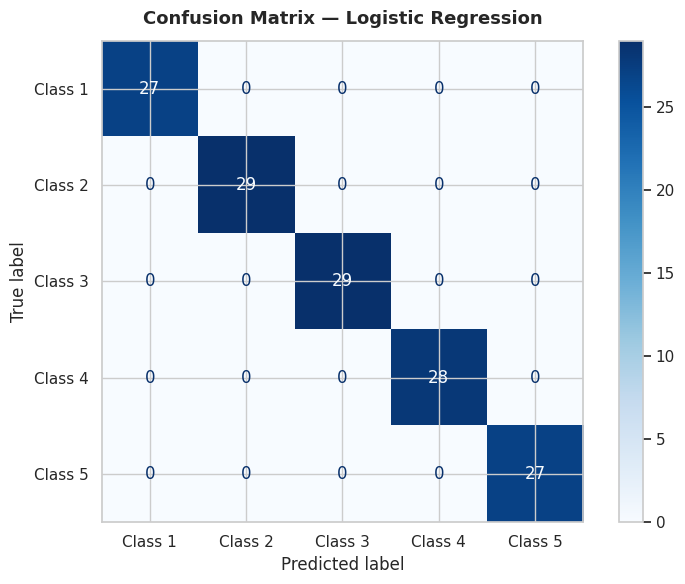

In [55]:
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[f'Class {i}' for i in sorted(y.unique())]
)
disp.plot(ax=ax, cmap='Blues', colorbar=True)

ax.set_title('Confusion Matrix — Logistic Regression',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()
